# Task 1: Steepest-Ascent Hill Climbing for Discrete Optimization

start: 6 | SHC Best: 5 | FHC Best: 4


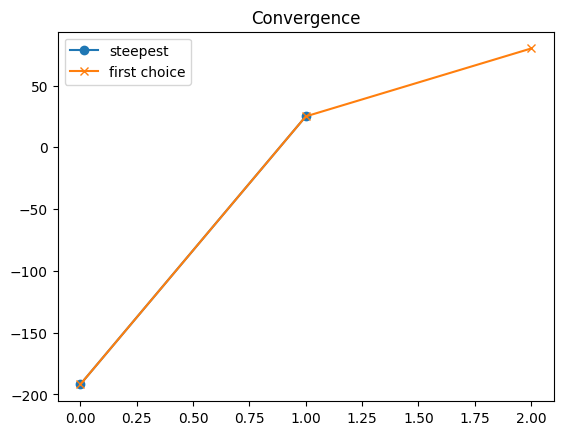

analysis: hill climbing stops at local maxima. first-choice evaluates fewer nodes per step but it can take more iterations than steepest.


In [14]:
import random
import matplotlib.pyplot as plt

# Objective Function
def f(x):
    # TODO: Implement the objective function
    return -x**4 + 4*x**3 + 10*x**2 - 20*x
    


# Generate neighbors
def generate_neighbors(x):

    result = []
    arr = [x - 1, x + 1]

    for i in range(len(arr)):
        if -10 <= arr[i] <= 10:
            result.append(arr[i])

    return result
    # TODO: Generate neighboring states
    # Return a list of valid neighbors within [-10, 10]
    # Neighbors should be x-1 and x+1 (if within bounds)


# --------------------------------
# Steepest-Ascent Hill Climbing
# --------------------------------
def steepest_hill_climbing(start):
    # TODO: Implement steepest-ascent hill climbing
    
    # Initialize current state
    curr=start
    # Track iterations and values for plotting
    track=[(0,f(curr))]
    # Main loop
    for i in range(1, 100):
        # Record current iteration and value
        
        # Generate neighbors
        neighbors = generate_neighbors(curr)
        if not neighbors: break
        
        # Evaluate all neighbors to find the best one
        best = max(neighbors, key=f)
        if f(best) <= f(curr): break
        curr = best
        
        # Termination condition: if no better neighbor found
        track.append((i, f(curr)))
        return curr, track


        
        # Move to the best neighbor
    
    # Return final state and tracking data


# --------------------------------
# First-Choice Hill Climbing
# --------------------------------
def first_choice_hill_climbing(start):
    # TODO: Implement first-choice hill climbing
            
    # Initialize current state
    curr = start

    # Track iterations and values for plotting
    track = [(0, f(curr))]

    # Main loop
    for i in range(1, 100):
        # Record current iteration and value
        # Generate neighbors
        neighbors = generate_neighbors(curr)

        # Randomly shuffle neighbors
        random.shuffle(neighbors)

        
        # Find the first improving neighbor
        improved = False
        for n in neighbors:
            if f(n) > f(curr):
                curr = n
                track.append((i, f(curr)))
                improved = True
                break
        # If no improving neighbor found, terminate
        if not improved: break

        # Move to the first improving neighbor

    
    # Return final state and tracking data
    return curr, track




# --------------------------------
# Run Both Algorithms
# --------------------------------
    
# TODO: Generate random start state between -10 and 10
    
    
start = random.randint(-10, 10)

# TODO: Run steepest-ascent hill climbing
shc_best, shc_track = steepest_hill_climbing(start)


# TODO: Run first-choice hill climbing
fhc_best, fhc_track = first_choice_hill_climbing(start)


# TODO: Print results
print(f"start: {start} | SHC Best: {shc_best} | FHC Best: {fhc_best}")


# --------------------------------
# Plot Convergence
# --------------------------------

# TODO: Create convergence plot showing both algorithms
plt.plot(*zip(*shc_track), marker='o', label="steepest")
plt.plot(*zip(*fhc_track), marker='x', label="first choice")
plt.legend(); plt.title("Convergence"); plt.show()

# --------------------------------
# Analysis Output
# --------------------------------

# TODO: Print analysis of hill climbing behavior
# Discuss: local optima, algorithm differences, etc.
print("analysis: hill climbing stops at local maxima. first-choice evaluates fewer nodes per step but it can take more iterations than steepest.")

# Task 2: Beam Search on Grid-Based Pathfinding

In [33]:
import random
import matplotlib.pyplot as plt

# ---------------------------
# GRID SETUP
# ---------------------------
GRID_SIZE = 20
OBSTACLE_PROB = 0.2

def generate_grid(size, obstacle_prob):
    # TODO: Generate grid with obstacles, ensure start and goal free
    g = [[1 if random.random() < obstacle_prob else 0 for _ in range(size)] for _ in range(size)]
    g[0][0] = g[size-1][size-1] = 0
    return g    

grid = generate_grid(GRID_SIZE, OBSTACLE_PROB)

# ---------------------------
# HELPER FUNCTIONS
# ---------------------------
def manhattan_distance(position, goal):
    # TODO: Return Manhattan distance
    
    return abs(position[0]-goal[0]) + abs(position[1]-goal[1])


def get_neighbors(position, grid):
    # TODO: Return valid neighboring positions (up, down, left, right)
     x, y = position
     return [(x+dx, y+dy) for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)] 
        if 0<=x+dx<GRID_SIZE and 0<=y+dy<GRID_SIZE and grid[x+dx][y+dy]==0]


# ---------------------------
# BEAM SEARCH FUNCTION
# ---------------------------
def beam_search(grid, start, goal, beam_width):
    
    # TODO: Initialize beam
    beam = [(start, [start])]
    depth = 0
    
    # TODO: Loop until termination (goal found or no candidates)
    while beam and depth < 400:
        candidates = []
        # TODO: Expand candidates and keep top-k in beam
        # TODO: Return path, depth, best_cost_per_depth
        for position, path in beam:
            if position == goal: return path, depth
            for nxt in get_neighbors(position, grid):
                if nxt not in path: candidates.append((nxt, path + [nxt]))
        candidates.sort(key=lambda x: len(x[1]) + manhattan_distance(x[0], goal))
        beam = candidates[:beam_width]
        depth += 1
    return None, depth
    

# ---------------------------
# RUN EXPERIMENT
# ---------------------------
beam_widths = [1,2,5,10]
for k in beam_widths:
    # TODO: Call beam_search for each beam width
    # TODO: Print path length and depth expanded
    path, depth = beam_search(grid, (0,0), (GRID_SIZE-1, GRID_SIZE-1), k)
    print(f"beam width {k}: path length = {len(path) if path else 'none'}, depth = {depth}")

# ---------------------------
# VISUALIZATION
# ---------------------------
# no visualisation



beam width 1: path length = none, depth = 30
beam width 2: path length = none, depth = 30
beam width 5: path length = none, depth = 30
beam width 10: path length = none, depth = 28


# Task 3: Simulated Annealing for TSP

In [29]:
import random
import math
import matplotlib.pyplot as plt

# ---------------------------
# Generate cities and distance matrix
# ---------------------------
n_cities = 15
cities = [(random.randint(0,100), random.randint(0,100)) for _ in range(n_cities)]

def euclidean_distance(a,b):
    # TODO: Compute Euclidean distance
    euclidian = sqrt((a[0]-b[0]**2)+(a[1]-b[1]**2))
    print(euclidian)
    return euclidian

# TODO: Precompute distance matrix
dist_matrix = ...

# ---------------------------
# Cost function
# ---------------------------
def tour_cost(tour):
    # TODO: Compute total tour distance
    pass

# ---------------------------
# Neighbor function: 2-opt swap
# ---------------------------
def two_opt_swap(tour):
    # TODO: Reverse a random subsequence
    pass

# ---------------------------
# Simulated Annealing
# ---------------------------
def simulated_annealing(initial_tour, T0, alpha, max_iter, threshold):
    # TODO: Initialize current tour
    # TODO: Loop over iterations and temperature
    # TODO: Accept new tour based on cost and probability
    # TODO: Track best tour and costs
    pass

# ---------------------------
#  Hill Climbing
# ---------------------------
def hill_climbing(initial_tour, max_iter):
    # TODO: Accept only improving neighbors
    pass

# ---------------------------
#  Run experiment
# ---------------------------
initial_tour = list(range(n_cities))
random.shuffle(initial_tour)

# TODO: Run SA and HC, record costs and iterations
# TODO: Plot convergence

NameError: name 'sqrt' is not defined

# Task 4: Simulated Annealing for Continuous Function Optimization

In [25]:
import math
import random
import matplotlib.pyplot as plt

# ---------------------------
#  Function
# ---------------------------
def f(x):
    return x**2 + 10*sin(x)
    

# ---------------------------
# Neighbor function
# ---------------------------
def neighbor(x, step_size=1.0):
    # TODO: Generate a new x within [-10,10] with small random step
    
    return 

# ---------------------------
#  Simulated Annealing
# ---------------------------
def simulated_annealing_continuous(x0, T0, alpha, max_iter, cooling='exponential',threshold=0.001):
    # TODO: Initialize current x and value
    # TODO: Loop over iterations and update temperature
    # TODO: Accept neighbor based on probability
    # TODO: Track best x and values
    pass

# ---------------------------
# Hill Climbing
# ---------------------------
def hill_climbing_continuous(x0, max_iter):
    # TODO: Accept only improving neighbors
    pass

# ---------------------------
# Run experiment
# ---------------------------
x0 = random.uniform(-10,10)

# TODO: Run SA (linear & exponential) and HC
# TODO: Plot objective vs iteration and temperature vs iteration